# Notebook 01: Exploratory Data Analysis (EDA)

## Đề tài 12: Dự đoán huỷ đặt phòng khách sạn

### Mục tiêu
- Mô tả bài toán và phân tích yêu cầu
- Data dictionary cho dataset Hotel Booking Demand
- Khám phá dữ liệu (EDA) với ≥3 biểu đồ kèm diễn giải
- Xác định rủi ro: data leakage, imbalance, missing values

### Kiến trúc repo
- `src/data/` — loader.py (đọc data), cleaner.py (xử lý missing/outlier)
- `src/features/` — builder.py (tạo features mới)
- `src/mining/` — association.py (Apriori), clustering.py (KMeans/DBSCAN)
- `src/models/` — supervised.py, semi_supervised.py, forecasting.py
- `src/evaluation/` — metrics.py, report.py
- `src/visualization/` — plots.py (hàm vẽ dùng chung)
- `notebooks/` — Trình bày kết quả, gọi hàm từ src/
- `configs/params.yaml` — Tham số (seed, split, hyperparams)
- `scripts/` — run_pipeline.py, run_papermill.py

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from src.data.loader import load_raw_data, get_data_dictionary, load_config
from src.visualization.plots import (
    plot_target_distribution,
    plot_cancel_by_category,
    plot_correlation_heatmap,
    plot_distribution,
)

config = load_config("../configs/params.yaml")
print("Config loaded successfully")

Config loaded successfully


## 1. Đặt vấn đề

**Bối cảnh**: Huỷ đặt phòng là vấn đề lớn trong ngành khách sạn, gây thất thu doanh thu và lãng phí tài nguyên. Dự đoán được booking nào sẽ bị huỷ giúp khách sạn:
- Tối ưu overbooking strategy
- Cải thiện revenue management
- Điều chỉnh chính sách đặt cọc/huỷ phòng

**Mục tiêu**: Pipeline khai phá dữ liệu hoàn chỉnh: luật kết hợp, phân cụm, phân lớp, bán giám sát, chuỗi thời gian.

**Tiêu chí thành công**: PR-AUC > 0.7, F1 > 0.7; actionable insights cho khách sạn.

## 2. Load và mô tả dữ liệu

In [2]:
df = load_raw_data("../data/raw/hotel_bookings.csv")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

[Loader] Loaded 119,390 rows × 32 columns from ../data/raw/hotel_bookings.csv
Shape: (119390, 32)

First 5 rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Data Dictionary

In [3]:
data_dict = get_data_dictionary()
dd_df = pd.DataFrame(
    [(k, v) for k, v in data_dict.items()],
    columns=["Column", "Description"]
)
dd_df

,Column,Description
0,hotel,Loại khách sạn: City Hotel hoặc Resort Hotel
1,is_canceled,"Booking bị huỷ hay không (0=không, 1=huỷ) – TA..."
2,lead_time,Số ngày giữa ngày đặt phòng và ngày đến (0 = đ...
3,arrival_date_year,Năm khách đến (2015-2017)
4,arrival_date_month,Tháng khách đến (January-December)
5,arrival_date_week_number,Tuần trong năm (1-53)
6,arrival_date_day_of_month,Ngày trong tháng (1-31)
7,stays_in_weekend_nights,Số đêm cuối tuần (Sat/Sun) khách ở
8,stays_in_week_nights,Số đêm trong tuần (Mon-Fri) khách ở
9,adults,Số người lớn


In [4]:
print("=" * 50)
print("BASIC STATISTICS")
print("=" * 50)
print(f"\nRows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nTarget (is_canceled):")
print(df["is_canceled"].value_counts())
print(f"\nCancel rate: {df['is_canceled'].mean():.2%}")
print(f"\nMissing values:")
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"\nDuplicates: {df.duplicated().sum()}")
df.describe()

BASIC STATISTICS

Rows: 119,390
Columns: 32

Target (is_canceled):
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Cancel rate: 37.04%

Missing values:
children         4
country        488
agent        16340
company     112593
dtype: int64

Duplicates: 31994


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


### ⚠️ Rủi ro Data Leakage

Cột `reservation_status` chứa trực tiếp thông tin huỷ (Canceled/Check-Out/No-Show) — đây là **data leakage** vì thông tin này chỉ có SAU khi booking kết thúc.

Cột `reservation_status_date` cũng tương tự.

→ **Phải loại bỏ 2 cột này trước khi train model.**

In [5]:
print("reservation_status distribution:")
print(df["reservation_status"].value_counts())
print(f"\n→ Perfect correlation with is_canceled = DATA LEAKAGE")

reservation_status distribution:
reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

→ Perfect correlation with is_canceled = DATA LEAKAGE


## 3. Exploratory Data Analysis

### 3.1 Phân bố target variable

In [6]:
# Biểu đồ 1: Target distribution
plot_target_distribution(df, save_path="../outputs/figures/01_target_dist.png")

**Diễn giải**: Dataset có 75,166 booking không huỷ (63%) vs 44,224 booking huỷ (37%). Đây là **imbalance nhẹ** nhưng cần theo dõi metric PR-AUC thay vì chỉ accuracy.

### 3.2 Cancellation rate theo loại khách sạn và tháng

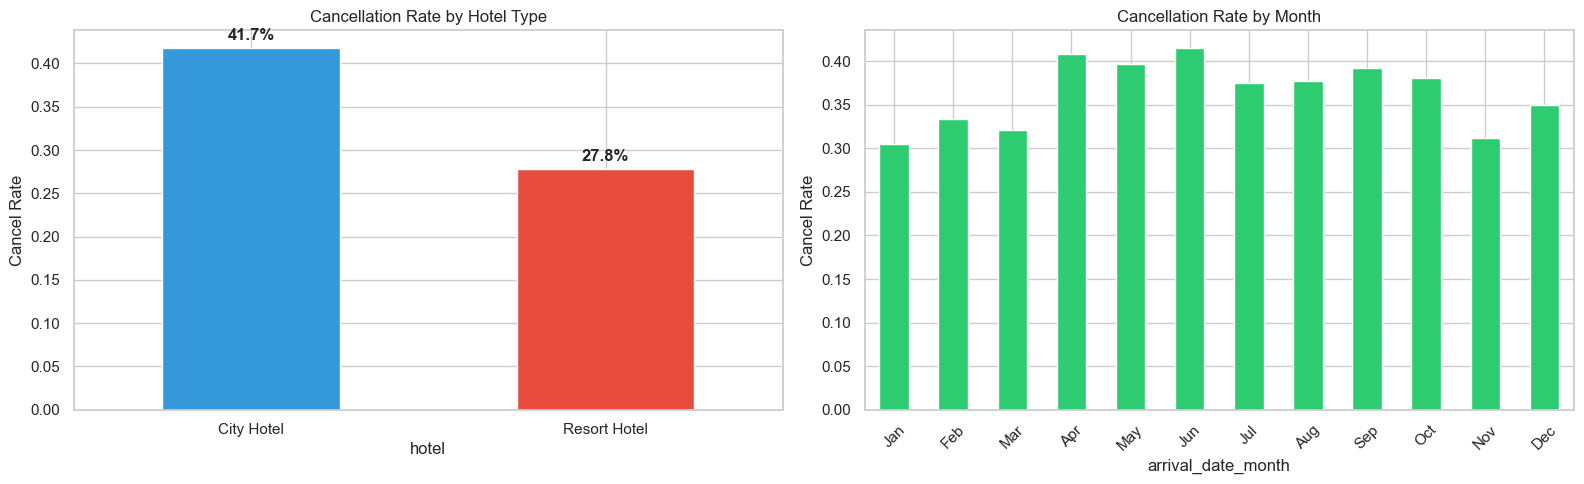

In [7]:
# Biểu đồ 2: Cancel by hotel type and month
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# By hotel
hotel_cancel = df.groupby("hotel")["is_canceled"].mean()
hotel_cancel.plot(kind="bar", ax=axes[0], color=["#3498db", "#e74c3c"], edgecolor="white")
axes[0].set_title("Cancellation Rate by Hotel Type")
axes[0].set_ylabel("Cancel Rate")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(hotel_cancel.values):
    axes[0].text(i, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")

# By month
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
month_cancel = df.groupby("arrival_date_month")["is_canceled"].mean().reindex(month_order)
month_cancel.plot(kind="bar", ax=axes[1], color="#2ecc71", edgecolor="white")
axes[1].set_title("Cancellation Rate by Month")
axes[1].set_ylabel("Cancel Rate")
axes[1].set_xticklabels([m[:3] for m in month_order], rotation=45)

plt.tight_layout()
plt.savefig("../outputs/figures/01_cancel_by_hotel_month.png", dpi=150, bbox_inches="tight")
plt.show()

**Diễn giải**: 
- **City Hotel** có tỷ lệ huỷ (~42%) cao hơn Resort Hotel (~28%)
- Tỷ lệ huỷ biến đổi theo mùa, cao nhất vào Summer

### 3.3 Ảnh hưởng của Lead Time

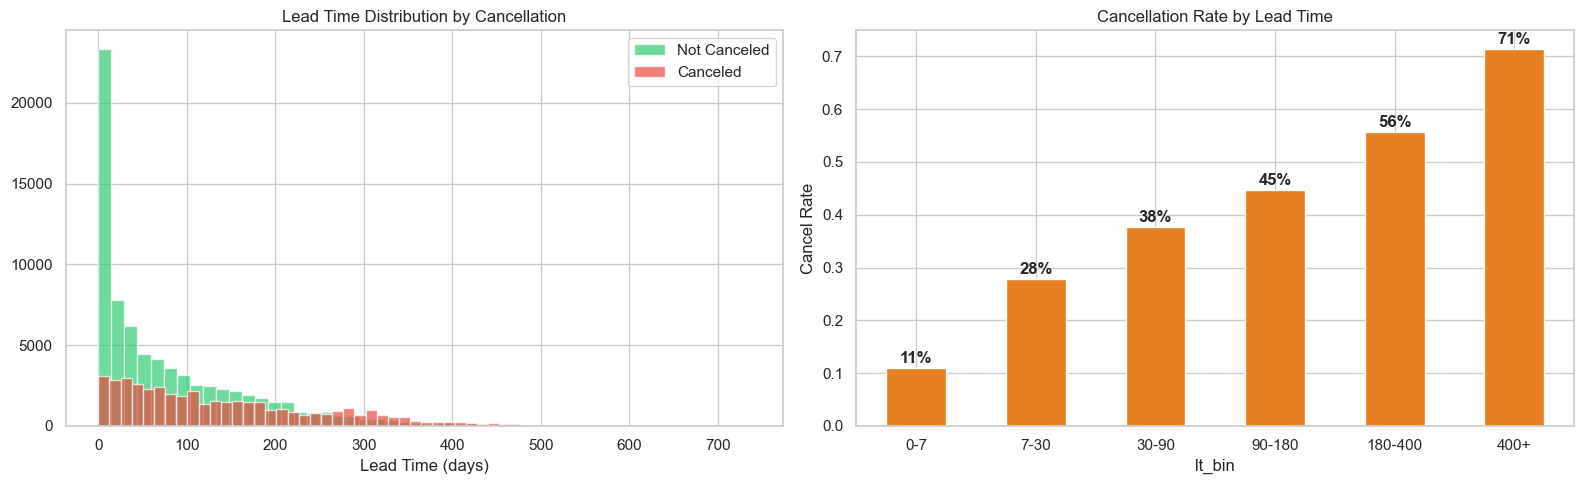

In [8]:
# Biểu đồ 3: Lead time vs cancellation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df[df["is_canceled"]==0]["lead_time"].hist(bins=50, ax=axes[0], alpha=0.7, label="Not Canceled", color="#2ecc71")
df[df["is_canceled"]==1]["lead_time"].hist(bins=50, ax=axes[0], alpha=0.7, label="Canceled", color="#e74c3c")
axes[0].set_title("Lead Time Distribution by Cancellation")
axes[0].set_xlabel("Lead Time (days)")
axes[0].legend()

# Binned cancel rate
bins = [0, 7, 30, 90, 180, 400, 800]
labels_lt = ["0-7", "7-30", "30-90", "90-180", "180-400", "400+"]
df["lt_bin"] = pd.cut(df["lead_time"], bins=bins, labels=labels_lt)
lt_cancel = df.groupby("lt_bin", observed=True)["is_canceled"].mean()
lt_cancel.plot(kind="bar", ax=axes[1], color="#e67e22", edgecolor="white")
axes[1].set_title("Cancellation Rate by Lead Time")
axes[1].set_ylabel("Cancel Rate")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for i, v in enumerate(lt_cancel.values):
    axes[1].text(i, v + 0.01, f"{v:.0%}", ha="center", fontweight="bold")
df = df.drop(columns=["lt_bin"])

plt.tight_layout()
plt.savefig("../outputs/figures/01_lead_time.png", dpi=150, bbox_inches="tight")
plt.show()

**Diễn giải**: Lead time dài → tỷ lệ huỷ cao hơn rõ rệt. Booking đặt trước 180+ ngày có tỷ lệ huỷ lên đến 60-70%. Đây là feature quan trọng nhất cho classification.

### 3.4 Deposit Type và Market Segment

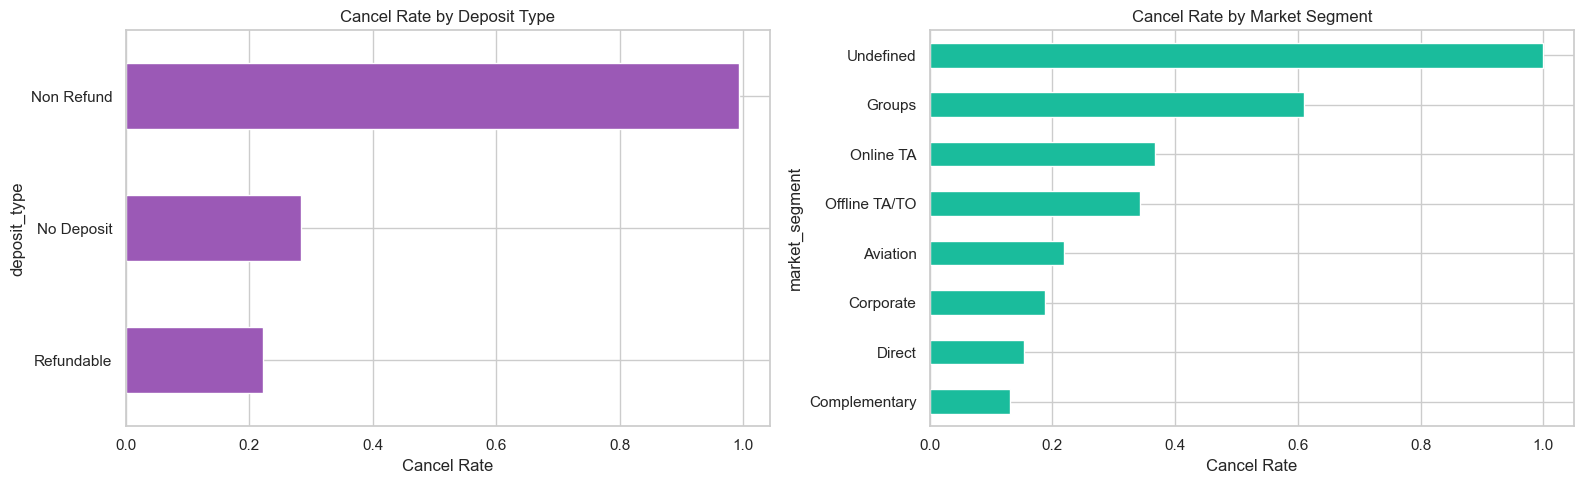

In [9]:
# Biểu đồ 4
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df.groupby("deposit_type")["is_canceled"].mean().sort_values().plot(
    kind="barh", ax=axes[0], color="#9b59b6", edgecolor="white")
axes[0].set_title("Cancel Rate by Deposit Type")
axes[0].set_xlabel("Cancel Rate")

df.groupby("market_segment")["is_canceled"].mean().sort_values().plot(
    kind="barh", ax=axes[1], color="#1abc9c", edgecolor="white")
axes[1].set_title("Cancel Rate by Market Segment")
axes[1].set_xlabel("Cancel Rate")

plt.tight_layout()
plt.savefig("../outputs/figures/01_deposit_segment.png", dpi=150, bbox_inches="tight")
plt.show()

**Diễn giải**: Non Refund deposit có cancel rate ~99%; Groups và Online TA cancel nhiều nhất.

### 3.5 Correlation Heatmap

In [10]:
# Biểu đồ 5
numeric_cols = ["is_canceled", "lead_time", "adr", "total_of_special_requests",
    "booking_changes", "previous_cancellations", "is_repeated_guest",
    "stays_in_week_nights", "stays_in_weekend_nights", "adults", "days_in_waiting_list"]
plot_correlation_heatmap(df[numeric_cols], figsize=(12, 8),
    save_path="../outputs/figures/01_correlation.png")

**Diễn giải**: Features có correlation cao nhất với `is_canceled`:
- `lead_time` (+): đặt sớm → hay huỷ
- `total_of_special_requests` (-): yêu cầu đặc biệt → ít huỷ
- `previous_cancellations` (+): lịch sử huỷ → dễ huỷ tiếp
- `is_repeated_guest` (-): khách quen → ít huỷ

## 4. Kết luận EDA

1. Dataset 119,390 bookings, imbalance nhẹ (37% cancel)
2. **Data leakage**: phải loại bỏ `reservation_status`, `reservation_status_date`
3. **Lead time** là predictor mạnh nhất
4. **City Hotel** huỷ nhiều hơn Resort Hotel
5. **Deposit type** ảnh hưởng lớn
6. Missing: `company` (94%), `agent` (14%), `country` (0.4%)

→ Tiếp theo: Notebook 02 - Tiền xử lý và Feature Engineering